In [1]:
import snp2cell
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
csvFile = pd.read_csv("../process/SNP/SNP2ell/20250215_network_table_2000.csv",index_col=0)

In [4]:
G = nx.from_pandas_edgelist(
        csvFile,
        source='TF',  # source column name
        target='gene',  # target column name
        edge_attr='width'  # weight column name (optional)
    )

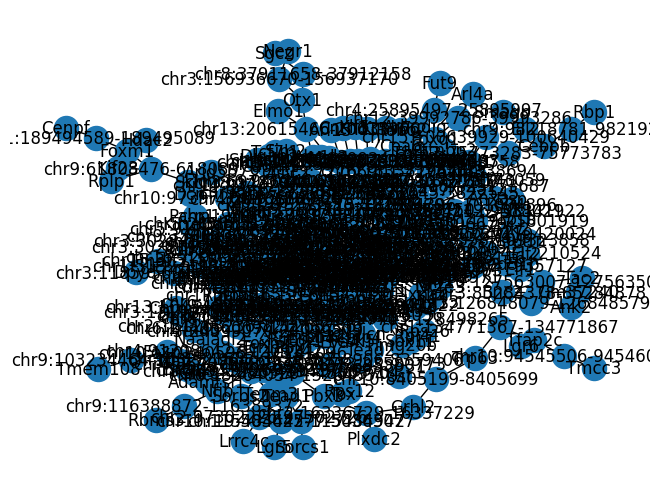

In [5]:
nx.draw_kamada_kawai(G, with_labels=True)

In [6]:
s2c = snp2cell.SNP2CELL()
s2c.add_grn_from_networkx(G)

In [7]:
snpscore = pd.read_csv("../process/framework/snps/20250213_SNPs_annoated_peaks_scenic.csv",index_col=0)

In [8]:
peak = snpscore["seqnames"] + ":" + snpscore["start"].astype(str) + "-" + snpscore["end"].astype(str)

In [9]:
peak_snp_dict =  {k: v for k, v in zip(peak, snpscore['has_snp'])}

In [10]:
gene_snp = pd.read_csv("../process/SNP/SNP2ell/20250206_prepare_gene_snp.csv",index_col=0)

In [11]:
gene_snp_dict ={k: v for k, v in zip(gene_snp["symbol"], gene_snp['has_snp'])}

In [12]:
peak_snp_dict.update(gene_snp_dict)

In [16]:
ad = sc.read("../process/framework/obj/rna_raw_scglue_prepare.h5ad")

In [24]:
ad.X = ad.layers["counts"].copy()

In [25]:
sc.pp.normalize_total(ad)
sc.pp.log1p(ad)
ad.raw = ad

In [27]:
label = pd.read_csv("../../2024.4_scATAC/processed_data/cluster/rna_annotation_scvi_mod.csv",index_col=0)

In [29]:
ad.obs["label"] = label["level1_anno"]

In [40]:
ad.obs["label"]

E125_1_AAACCCAAGTCATGAA-1    stem cells
E125_1_AAACCCACAAGACCGA-1    stem cells
E125_1_AAACCCACATGCACTA-1       Transit
E125_1_AAACCCAGTCAGTCGC-1    stem cells
E125_1_AAACCCAGTCCACGCA-1    stem cells
                                ...    
E145_2_TTTGGTTCATACCATG-1         K5(-)
E145_2_TTTGGTTCATGCCGGT-1         K5(-)
E145_2_TTTGGTTTCGTAGGAG-1       Transit
E145_2_TTTGTTGCACACCGAC-1       Transit
E145_2_TTTGTTGTCAACTGGT-1       Transit
Name: label, Length: 19404, dtype: category
Categories (7, object): ['K5(-)', 'K6+ cells', 'K14(-)', 'Mature K5(-) ', 'Shh(+)', 'Transit', 'stem cells']

In [30]:
s2c.add_score(score_dct=peak_snp_dict, score_key="has_snp")

[INFO - add_score - 2025-02-15 11:24:26,548]: adding score: has_snp
[INFO - add_score - 2025-02-15 11:24:27,102]: propagating score: has_snp
[INFO - add_score - 2025-02-15 11:24:27,117]: storing score has_snp
[INFO - rand_sim - 2025-02-15 11:24:27,120]: ----- starting rand_sim -----
[INFO - rand_sim - 2025-02-15 11:24:27,121]: create 1000 permutations of score has_snp
[INFO - rand_sim - 2025-02-15 11:24:27,292]: propagating permutations
[INFO - loop_parallel - 2025-02-15 11:24:27,294]: using 48 cores
100%|██████████| 1000/1000 [00:22<00:00, 45.42it/s]
[INFO - rand_sim - 2025-02-15 11:24:49,926]: storing scores under key has_snp
[INFO - rand_sim - 2025-02-15 11:24:50,060]: ----- finished rand_sim -----
[INFO - add_score_statistics - 2025-02-15 11:24:50,063]: ----- starting add_score_statistics -----
[INFO - add_score_statistics - 2025-02-15 11:24:50,063]: adding statistics for: has_snp
[INFO - add_score_statistics - 2025-02-15 11:24:50,645]: ----- finished add_score_statistics -----


In [33]:
s2c.link_adata(ad,overwrite=True)
s2c.adata_add_de_scores(groupby="label", check=False)

[INFO - adata_add_de_scores - 2025-02-15 11:25:26,987]: ----- starting adata_add_de_scores -----
[INFO - adata_add_de_scores - 2025-02-15 11:25:26,992]: finding DE genes for annotation label
[INFO - adata_add_de_scores - 2025-02-15 11:27:08,413]: ranking by upregulation...
[INFO - add_score - 2025-02-15 11:27:08,452]: adding score: DE_stem cells__score
[INFO - add_score - 2025-02-15 11:27:09,043]: adding score: DE_K5(-)__score
[INFO - add_score - 2025-02-15 11:27:09,470]: adding score: DE_Transit__score
[INFO - add_score - 2025-02-15 11:27:09,894]: adding score: DE_Mature K5(-) __score
[INFO - add_score - 2025-02-15 11:27:10,324]: adding score: DE_K6+ cells__score
[INFO - add_score - 2025-02-15 11:27:10,752]: adding score: DE_K14(-)__score
[INFO - add_score - 2025-02-15 11:27:11,178]: adding score: DE_Shh(+)__score
[INFO - propagate_scores - 2025-02-15 11:27:11,652]: ----- starting propagate_scores -----
[INFO - propagate_scores - 2025-02-15 11:27:11,654]: propagating scores: ['DE_K14(

In [34]:
s2c.adata_combine_de_scores(
    group_key="label", score_key="has_snp", suffix="__zscore"
)

[INFO - combine_scores - 2025-02-15 11:29:16,588]: ----- starting combine_scores -----
[INFO - combine_scores - 2025-02-15 11:29:16,592]: combining scores: [('DE_stem cells__score__zscore', 'has_snp__zscore'), ('DE_K5(-)__score__zscore', 'has_snp__zscore'), ('DE_Transit__score__zscore', 'has_snp__zscore'), ('DE_Mature K5(-) __score__zscore', 'has_snp__zscore'), ('DE_K6+ cells__score__zscore', 'has_snp__zscore'), ('DE_K14(-)__score__zscore', 'has_snp__zscore'), ('DE_Shh(+)__score__zscore', 'has_snp__zscore')]
[INFO - combine_scores - 2025-02-15 11:29:16,610]: ----- finished combine_scores -----
[INFO - combine_scores_rand - 2025-02-15 11:29:16,612]: ----- starting combine_scores_rand -----
[INFO - combine_scores_rand - 2025-02-15 11:29:16,614]: combining scores: [('DE_label__score', 'has_snp', '__zscore')]
[INFO - combine_scores_rand - 2025-02-15 11:29:17,323]: ----- finished combine_scores_rand -----
[INFO - add_score_statistics - 2025-02-15 11:29:17,326]: ----- starting add_score_stat

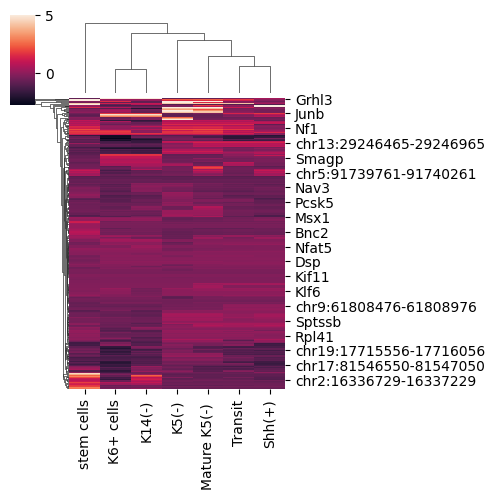

In [38]:
plt_df = s2c.get_scores(regex="min.+has_snp__zscore.*zscore$")
plt_df = plt_df.rename(columns=s2c.rename_column)

sns.clustermap(plt_df, figsize=(5, 5),vmax = 5)
plt.savefig("../result/SNP/20250213_snp2cell_round1/20250215_GRN_hm2.pdf")

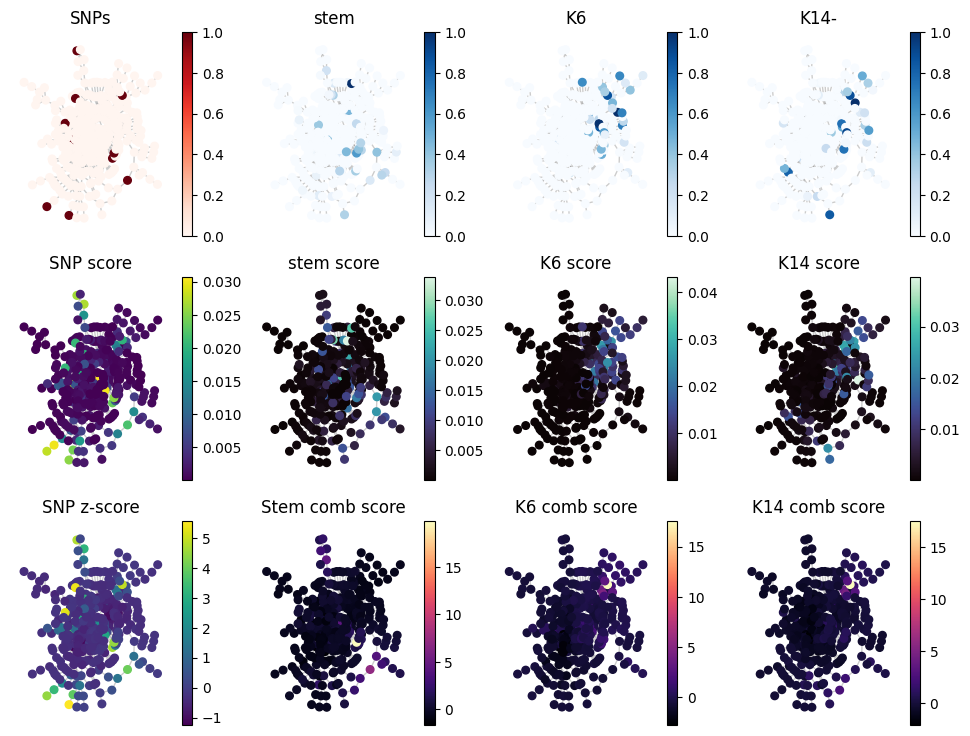

In [39]:
plot_scores = [
    (s2c.scores["has_snp"], "Reds", "SNPs"),
    (s2c.scores["DE_stem cells__score"], "Blues", "stem"),
    (s2c.scores["DE_K6+ cells__score"], "Blues", "K6"),
    (s2c.scores["DE_K14(-)__score"], "Blues", "K14-"),
    (s2c.scores_prop["has_snp"], "viridis", "SNP score"),
    (s2c.scores_prop["DE_stem cells__score"], "mako", "stem score"),
    (s2c.scores_prop["DE_K6+ cells__score"], "mako", "K6 score"),
    (s2c.scores_prop["DE_K14(-)__score"], "mako", "K14 score"),
    (s2c.scores_prop["has_snp__zscore"], "viridis", "SNP z-score"),
    (
        s2c.scores_prop["min(DE_stem cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Stem comb score",
    ),
    (
        s2c.scores_prop["min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K6 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K14 comb score",
    ),
]
nrow, ncol = 3, 4
plt.rcParams["figure.figsize"] = (ncol * 3, nrow * 3)
fig, axs = plt.subplots(nrow, ncol)
pos = nx.kamada_kawai_layout(G)
for k, (score_val, col_map, ax_title) in enumerate(plot_scores):
    i, j = int(k) // 4, k % 4
    ec = nx.draw_networkx_edges(G, pos, alpha=0.2, ax=axs[i, j])
    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=s2c.scores_prop.index.tolist(),
        node_color=score_val.tolist(),
        node_size=30,
        cmap=plt.colormaps[col_map],
        ax=axs[i, j],
    )
    plt.colorbar(nc)
    axs[i, j].set_title(ax_title)
    axs[i, j].axis("off")

plt.savefig("../result/SNP/20250213_snp2cell_round1/20250216_GRN_snp2.pdf")

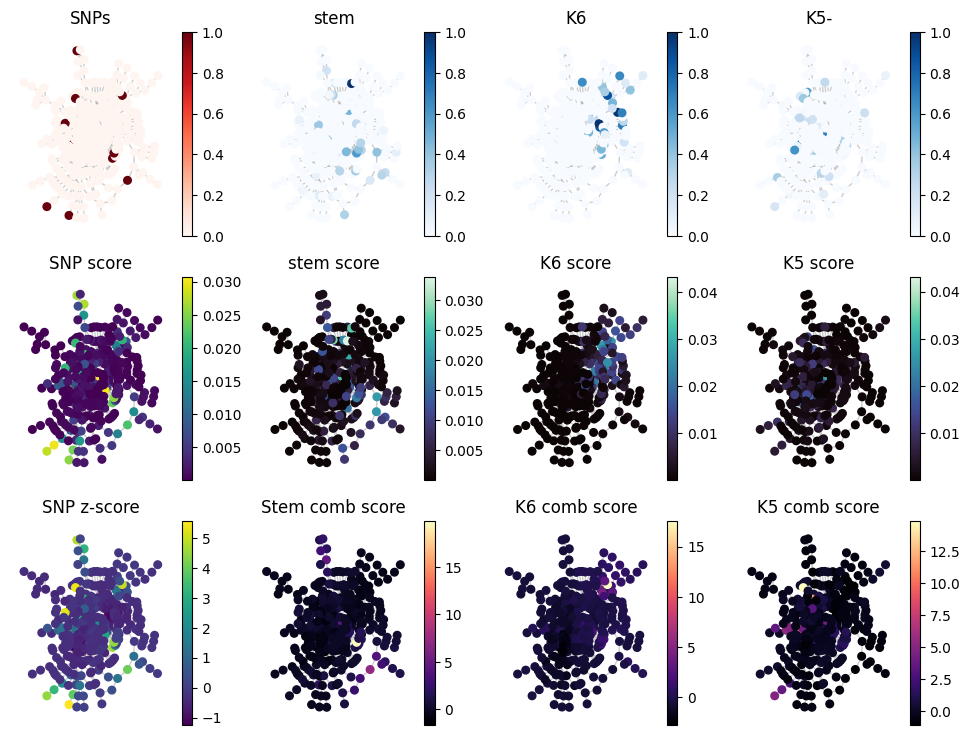

In [41]:
plot_scores = [
    (s2c.scores["has_snp"], "Reds", "SNPs"),
    (s2c.scores["DE_stem cells__score"], "Blues", "stem"),
    (s2c.scores["DE_K6+ cells__score"], "Blues", "K6"),
    (s2c.scores["DE_K5(-)__score"], "Blues", "K5-"),
    (s2c.scores_prop["has_snp"], "viridis", "SNP score"),
    (s2c.scores_prop["DE_stem cells__score"], "mako", "stem score"),
    (s2c.scores_prop["DE_K6+ cells__score"], "mako", "K6 score"),
    (s2c.scores_prop["DE_K5(-)__score"], "mako", "K5 score"),
    (s2c.scores_prop["has_snp__zscore"], "viridis", "SNP z-score"),
    (
        s2c.scores_prop["min(DE_stem cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Stem comb score",
    ),
    (
        s2c.scores_prop["min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K6 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K5(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K5 comb score",
    ),
]
nrow, ncol = 3, 4
plt.rcParams["figure.figsize"] = (ncol * 3, nrow * 3)
fig, axs = plt.subplots(nrow, ncol)
pos = nx.kamada_kawai_layout(G)
for k, (score_val, col_map, ax_title) in enumerate(plot_scores):
    i, j = int(k) // 4, k % 4
    ec = nx.draw_networkx_edges(G, pos, alpha=0.2, ax=axs[i, j])
    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=s2c.scores_prop.index.tolist(),
        node_color=score_val.tolist(),
        node_size=30,
        cmap=plt.colormaps[col_map],
        ax=axs[i, j],
    )
    plt.colorbar(nc)
    axs[i, j].set_title(ax_title)
    axs[i, j].axis("off")

plt.savefig("../result/SNP/20250213_snp2cell_round1/20250216_GRN_snp2.pdf")